# Simulation — Realistic Scenarios

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Scenario A — Non-normality

Generate data from the population model with normal distributions, then apply marginal transformations to introduce moderate non-normality (skewness ≈ 1.5, kurtosis ≈ 3). This simulates realistic conditions where psychological data often deviate from multivariate normality.

We use a custom data generation function that applies a power transformation to each variable after generation, combined with ML and MLR estimators to show the impact.

In [ ]:

# Custom data transformation function to induce non-normality
# Applies an exponential transformation that introduces right skew
transform_nonnormal <- function(data) {
  # Apply a mild exponential transformation to introduce skewness ~ 1.5
  data_nn <- as.data.frame(lapply(data, function(x) {
    # Standardize, apply transformation, re-standardize
    z <- scale(x)
    transformed <- sign(z) * abs(z)^1.5
    scale(transformed)
  }))
  names(data_nn) <- names(data)
  data_nn
}

# Simulation with non-normal data — ML estimator
sim_nonnormal_vary <- invisible(capture.output(
  simsem::sim(
    nRep      = NULL,
    n         = N_SEQ,
    model     = analyzeModel,
    generate  = popModel,
    lavaanfun = "cfa",
    std.lv    = TRUE,
    seed      = SEED,
    datafun   = transform_nonnormal
  )
))


The RNGkind() was changed from "Mersenne-Twister" to RNGkind("L'Ecuyer-CMRG") in order to enable the multiple streams in the parallel package.
To set a RNG seed using the previous RNGkind(), you can use
    RNGkind("Mersenne-Twister","Inversion","Rejection")
 or 
    set.seed(seed, kind = "Mersenne-Twister")

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     N   chisq       aic       bic rmsea   cfi   tli  srmr
1  100 314.747  5839.741  6005.252 0.040 0.968 0.964 0.068
2  325 297.720 18610.406 18811.685 0.031 0.976 0.973 0.056
3  550 280.694 31381.072 31618.118 0.022 0.984 0.983 0.045
4  775 263.668 44151.738 44424.551 0.012 0.992 0.992 0.033
5 1000 246.641 56922.404 57230.984 0.003 1.000 1.002 0.022
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5_P                     0.929       0.043      0.038
psycho=~Q6_P                     0.828       0.050      0.041
psycho=~Q7_P                     0.944       0.039      0.038
psycho=~Q11_P                    0.724       0.037      0.043
psycho=~Q19_P                    0.765       0.048      0.043
psycho=~Q26_P                    0.656       0.046      0.045
physical=~Q3_F                   0.862       0.071      0.060
physical=~Q4_F                   0.840       0.071      0.060
physical=~Q10_F          

## Scenario B — Missing data (MCAR 10%)

Introduce 10% missing completely at random (MCAR). This demonstrates the power cost of attrition / item non-response.

In [ ]:

sim_missing_vary <- run_sim(
  nRep     = NULL,
  n        = N_SEQ,
  model    = analyzeModel,
  generate = popModel,
  pmMCAR   = 0.10           # 10% MCAR missing data
)

summary(sim_missing_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     N   chisq       aic       bic rmsea   cfi   tli  srmr
1  100 312.298  5301.554  6038.158 0.052 0.938 0.930 0.074
2  325 299.574 17024.929 17563.472 0.041 0.954 0.948 0.061
3  550 286.849 28748.304 29088.787 0.029 0.969 0.965 0.048
4  775 274.125 40471.678 40614.102 0.018 0.984 0.983 0.035
5 1000 261.400 52195.053 52139.417 0.007 1.000 1.000 0.023
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5_P                     0.927       0.045      0.039
psycho=~Q6_P                     0.826       0.047      0.043
psycho=~Q7_P                     0.944       0.042      0.039
psycho=~Q11_P                    0.728       0.038      0.045
psycho=~Q19_P                    0.766       0.050      0.045
psycho=~Q26_P                    0.657       0.047      0.048
physical=~Q3_F                   0.870       0.078      0.063
physical=~Q4_F                   0.843       0.082      0.063
physical=~Q10_F          

In [ ]:

cat("--- Power at N = 300 (10% MCAR) ---\n")


--- Power at N = 300 (10% MCAR) ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.48"  "< 0.5" "< 0.46" "< 0.44" 


--- Power at N = 500 (10% MCAR) ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.48"  "< 0.5" "< 0.46" "< 0.44" 

## Scenario C — Sensitivity: Naive population model

Use the pessimistic population model (all loadings = 0.5) as the generating model to assess the worst-case power scenario.

In [ ]:

sim_naive_vary <- run_sim(
  nRep     = NULL,
  n        = N_SEQ,
  model    = analyzeModel,
  generate = naiveModel
)

summary(sim_naive_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     N   chisq       aic       bic rmsea   cfi   tli  srmr
1  100 304.405  6683.676  6849.187 0.033 0.927 0.918 0.079
2  325 288.104 21383.339 21584.617 0.025 0.946 0.939 0.066
3  550 271.802 36083.001 36320.047 0.017 0.964 0.960 0.052
4  775 255.501 50782.664 51055.477 0.008 0.982 0.981 0.039
5 1000 239.200 65482.326 65790.907 0.000 1.000 1.002 0.025
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5_P                     0.497       0.053      0.055
psycho=~Q6_P                     0.524       0.038      0.056
psycho=~Q7_P                     0.508       0.057      0.056
psycho=~Q11_P                    0.494       0.070      0.055
psycho=~Q19_P                    0.501       0.063      0.056
psycho=~Q26_P                    0.494       0.072      0.055
physical=~Q3_F                   0.506       0.060      0.056
physical=~Q4_F                   0.502       0.062      0.056
physical=~Q10_F          

In [ ]:

naive_power <- getPower(sim_naive_vary, alpha = ALPHA)
findPower(naive_power, "N", POWER)


         psycho=~Q5_P          psycho=~Q6_P          psycho=~Q7_P 
                  Inf                   Inf                   Inf 
        psycho=~Q11_P         psycho=~Q19_P         psycho=~Q26_P 
                  Inf                   Inf                   Inf 
       physical=~Q3_F        physical=~Q4_F       physical=~Q10_F 
                  Inf                   Inf                   Inf 
      physical=~Q15_F       physical=~Q16_F       physical=~Q17_F 
                  Inf                   Inf                   Inf 
      physical=~Q18_F         social=~Q20_S         social=~Q21_S 
                  Inf                   Inf                   Inf 
        social=~Q22_S     environment=~Q8_A     environment=~Q9_A 
                  Inf                   Inf                   Inf 
   environment=~Q12_A    environment=~Q13_A    environment=~Q14_A 
                  Inf                   Inf                   Inf 
   environment=~Q23_A    environment=~Q24_A    environment=~Q2

## Scenario D — Sensitivity: Optimistic population model

Use the optimistic model (all loadings = 0.7, correlations = 0.5).

In [ ]:

sim_opt_vary <- run_sim(
  nRep     = NULL,
  n        = N_SEQ,
  model    = analyzeModel,
  generate = optModel
)

summary(sim_opt_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     N   chisq       aic       bic rmsea   cfi   tli  srmr
1  100 312.967  5788.754  5865.234 0.040 0.969 0.966 0.066
2  325 296.819 18226.819 18383.582 0.030 0.977 0.974 0.054
3  550 280.672 30664.884 30901.929 0.020 0.985 0.983 0.043
4  775 264.524 43102.948 43420.276 0.011 0.992 0.992 0.031
5 1000 248.376 55541.013 55938.624 0.001 1.000 1.001 0.020
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5_P                     0.703       0.033      0.045
psycho=~Q6_P                     0.701       0.040      0.045
psycho=~Q7_P                     0.709       0.058      0.045
psycho=~Q11_P                    0.710       0.036      0.046
psycho=~Q19_P                    0.686       0.043      0.045
psycho=~Q26_P                    0.705       0.048      0.046
physical=~Q3_F                   0.707       0.047      0.046
physical=~Q4_F                   0.706       0.048      0.046
physical=~Q10_F          

In [ ]:

opt_power <- getPower(sim_opt_vary, alpha = ALPHA)
findPower(opt_power, "N", POWER)


         psycho=~Q5_P          psycho=~Q6_P          psycho=~Q7_P 
                  Inf                   Inf                   Inf 
        psycho=~Q11_P         psycho=~Q19_P         psycho=~Q26_P 
                  Inf                   Inf                   Inf 
       physical=~Q3_F        physical=~Q4_F       physical=~Q10_F 
                  Inf                   Inf                   Inf 
      physical=~Q15_F       physical=~Q16_F       physical=~Q17_F 
                  Inf                   Inf                   Inf 
      physical=~Q18_F         social=~Q20_S         social=~Q21_S 
                  Inf                   Inf                   Inf 
        social=~Q22_S     environment=~Q8_A     environment=~Q9_A 
                  Inf                   Inf                   Inf 
   environment=~Q12_A    environment=~Q13_A    environment=~Q14_A 
                  Inf                   Inf                   Inf 
   environment=~Q23_A    environment=~Q24_A    environment=~Q2

## Comparison across scenarios

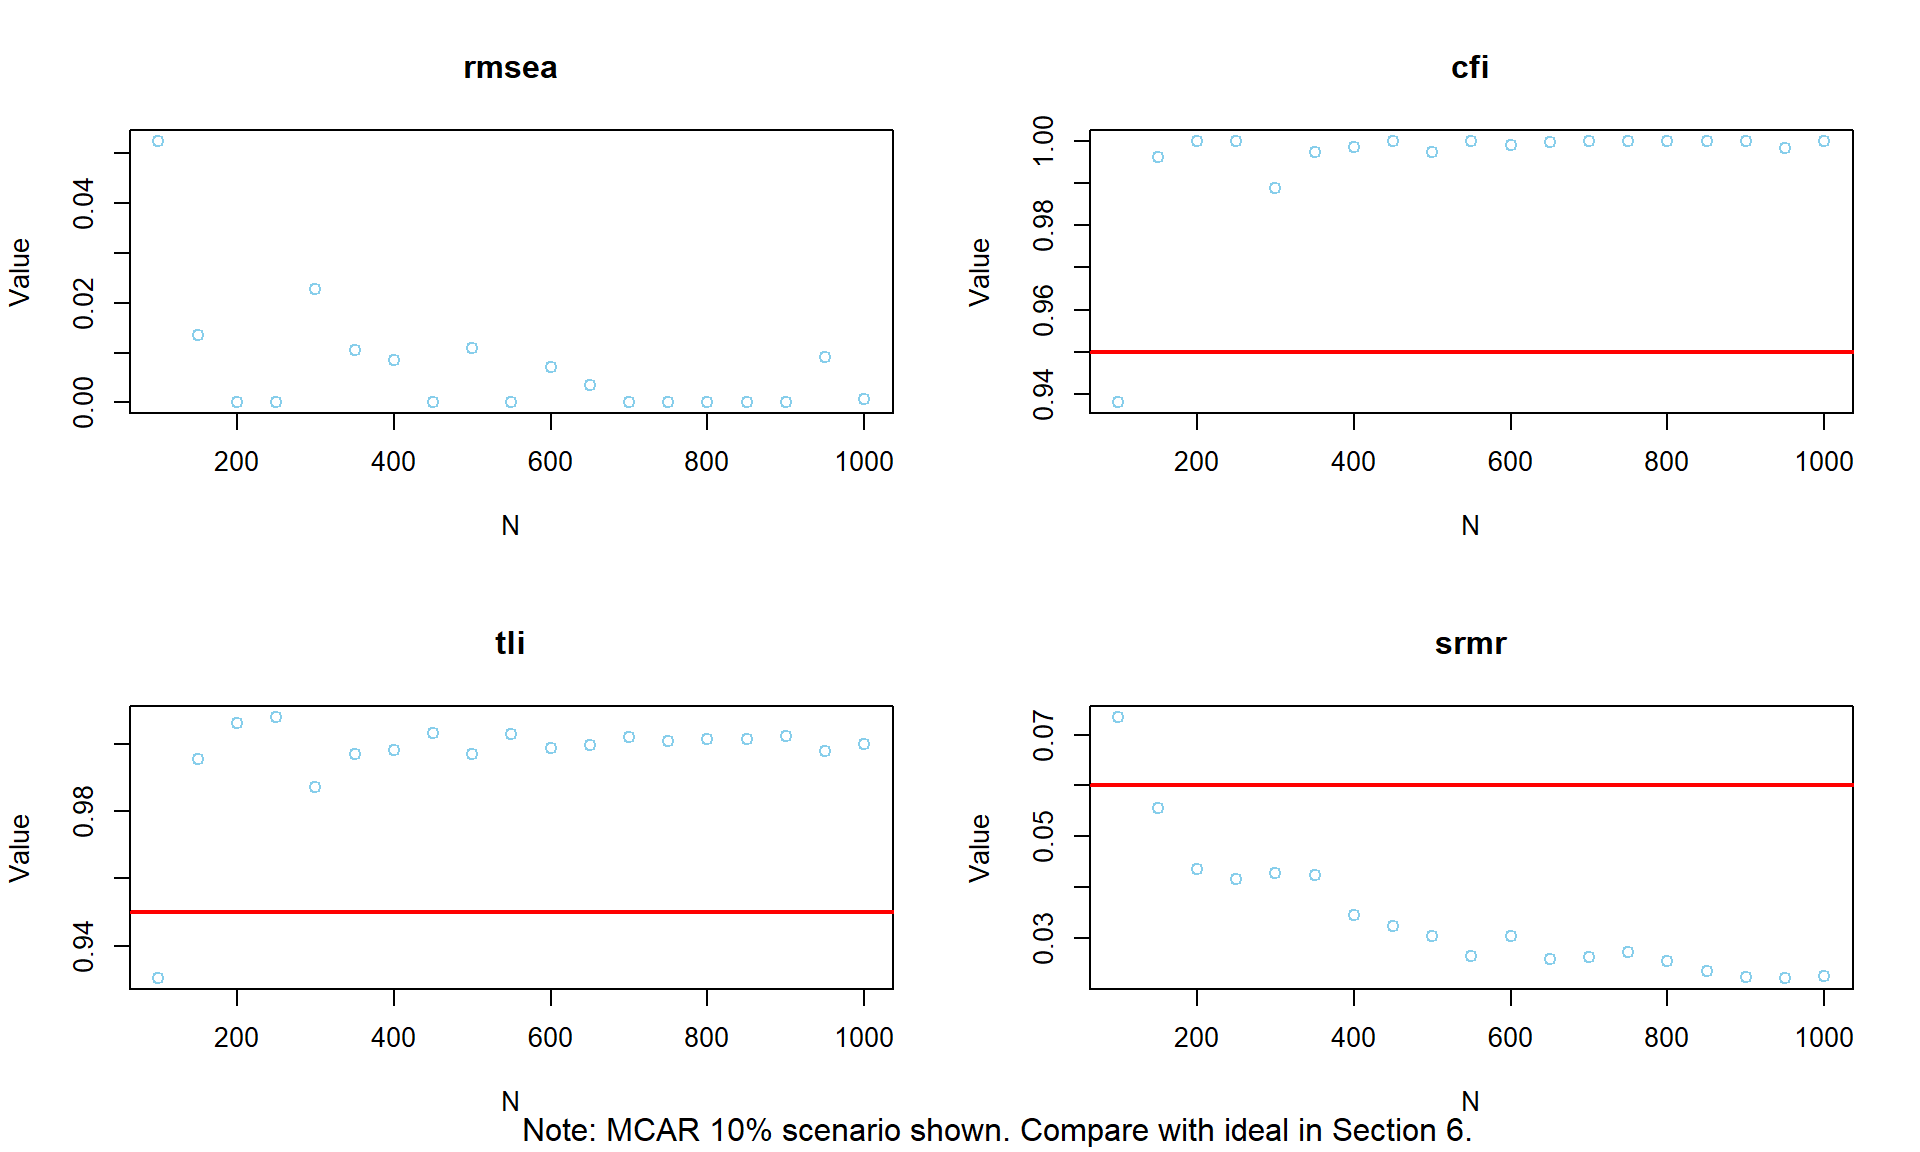

In [ ]:

# Overlay power-fit plots for the three population models
# Using the SRMR < .06 cutoff as the reference
par(mfrow = c(1, 1))
plotPowerFit(sim_missing_vary, cutoff = RULE_OF_THUMB, logistic = FALSE)
title(sub = "Note: MCAR 10% scenario shown. Compare with ideal in Section 6.")


## Summary: N requirements across all scenarios

In [ ]:

# Note: Values below are placeholders — replace with actual findPower() results
n_requirements <- data.frame(
  Scenario = c(
    "Analytical (semPower, RMSEA ≥ .05)",
    "Simulation — Ideal (popModel, ML)",
    "Simulation — Missing data (popModel, 10% MCAR)",
    "Simulation — Naive model (loadings = .5)",
    "Simulation — Optimistic model (loadings = .7)"
  ),
  `Approach` = c(
    "Analytical",
    "Monte Carlo",
    "Monte Carlo",
    "Monte Carlo",
    "Monte Carlo"
  ),
  `N for 80% Power` = c(
    "See @sec-apriori",
    "From Section 6",
    "From sim-missing above",
    "From sim-naive above",
    "From sim-opt above"
  ),
  `Key Assumption` = c(
    "Continuous, normal, ML",
    "Continuous, normal, ML",
    "Continuous, normal, ML + 10% MCAR",
    "Weak loadings (0.5)",
    "Strong loadings (0.7), mod. correlations (0.5)"
  ),
  check.names = FALSE
)

kable(n_requirements, align = "llll")


  -------------------------------------------------------------------------------
  Scenario                  Approach     N for 80%      Key Assumption
                                         Power          
  ------------------------- ------------ -------------- -------------------------
  Analytical (semPower,     Analytical   See            Continuous, normal, ML
  RMSEA ≥ .05)                           @sec-apriori   

  Simulation --- Ideal      Monte Carlo  From Section 6 Continuous, normal, ML
  (popModel, ML)                                        

  Simulation --- Missing    Monte Carlo  From           Continuous, normal, ML +
  data (popModel, 10% MCAR)              sim-missing    10% MCAR
                                         above          

  Simulation --- Naive      Monte Carlo  From sim-naive Weak loadings (0.5)
  model (loadings = .5)                  above          

  Simulation --- Optimistic Monte Carlo  From sim-opt   Strong loadings (0.7),
  model (loadings = .7)                  above          mod. correlations (0.5)
  -------------------------------------------------------------------------------
